# Tech Challenge — Fase 2
# Classificação de Qualidade de Vinhos com Machine Learning
### Relatório técnico **executável** (notebook autocontido)

**Grupo:** Efraim Oliveira · Érica Tarsis · Ricardo Moraes · Rodrigo Bernardino · Thiago Galvão

POSTECH DTAT — São Paulo, 2026

---
## Como ler este notebook
Versão **executável** do relatório, na **mesma ordem** do documento. Cada etapa traz o *porquê* (texto) seguido do código que a executa.

> **Autocontido:** todo o código está aqui. Basta o `WineQT.csv` ao lado do notebook e *Run All*.

**Governança aplicada:**
- **Reprodutibilidade:** semente fixa (`SEED = 43`). *Escolhemos **43** (primo), por decisão de grupo*.
- **Qualidade:** estatísticas sobre a **base limpa (1.018)**, nunca o bruto (1.143).
- **Sem vazamento:** padronização **dentro** do pipeline, após o split.
- **Rigor estatístico:** diferenças entre modelos passam por **McNemar**, **comparação pareada por dobras** e **bootstrap** — não confiamos no F1 de uma só partição.

## 0. Instalação e Configuração
As células **não** executam `pip install` (evita travamentos no VS Code). Instale uma vez no terminal:
```bash
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels scipy shap notebook
```
**Referência:** `pandas≥2.0`, `scikit-learn≥1.3`, `matplotlib≥3.7`, `statsmodels≥0.14`, `shap≥0.44`. O `shap` é opcional.

In [ ]:
# >>> Seção 0 — imports, semente, estilo padronizado e auxiliares de gráfico
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

SEED = 43                      # 43 é primo (decisão de grupo); substitui o difundido 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
LARANJA, AZUL = "#C55A11", "#2F5496"          # 0 = Baixa/Média | 1 = Alta
PALETA = ["#2F5496", "#C55A11", "#2E8B6F", "#7B5EA7", "#BF8F00", "#595959", "#A6342B"]

def br(x, dec=3): return f"{x:.{dec}f}".replace(".", ",")     # padrão pt-BR
def eixo_virgula(ax, eixo="x", dec=2):
    f = mticker.FuncFormatter(lambda v, _: f"{v:.{dec}f}".replace(".", ","))
    (ax.xaxis if eixo == "x" else ax.yaxis).set_major_formatter(f)
def anota_vertical(ax, vals, total=None, folga=0.32):         # rótulo + FOLGA (sem colisão c/ título)
    ymax = max(vals) if len(vals) else 1; ax.set_ylim(0, ymax*(1+folga))
    for i, v in enumerate(vals):
        t = f"{v:,.0f}".replace(",", ".") if total is None else f"{v:,.0f}\n({v/total:.0%})".replace(",", ".")
        ax.text(i, v+ymax*0.02, t, ha="center", va="bottom", fontsize=10, fontweight="bold")
def anota_h_pos(ax, vals, folga=0.18, dec=3):                 # barras horizontais só positivas
    xmax = max(vals) if len(vals) else 1; ax.set_xlim(0, xmax*(1+folga))
    for i, v in enumerate(vals): ax.text(v+xmax*0.01, i, br(v, dec), va="center", fontsize=10, fontweight="bold")
def barh_signed(ax, labels, vals, cor_pos=AZUL, cor_neg=LARANJA, dec=3, folga=0.16):
    # barras COM SINAL: rótulo do lado da ponta + xlim simétrico (corrige a colisão da Fig. 14)
    ax.barh(labels, vals, color=[cor_pos if v >= 0 else cor_neg for v in vals], edgecolor="white")
    ax.axvline(0, color="0.4", lw=0.8); vmin, vmax = min(vals), max(vals); span = (vmax-vmin) or 1
    ax.set_xlim(vmin-span*folga*2.2, vmax+span*folga*2.2)
    for i, v in enumerate(vals):
        ax.text(v+(span*0.015 if v >= 0 else -span*0.015), i, br(v, dec),
                va="center", ha="left" if v >= 0 else "right", fontsize=9.5, fontweight="bold")
print(f"Ambiente configurado. pandas {pd.__version__} | numpy {np.__version__} | SEED = {SEED}")


# --- Rótulos em português para exibição de tabelas (alinhamento com o relatório) ---
NOMES_PT = {
    "fixed acidity": "Acidez fixa", "volatile acidity": "Acidez volátil", "citric acid": "Ácido cítrico",
    "residual sugar": "Açúcar residual", "chlorides": "Cloretos", "free sulfur dioxide": "Dióxido de enxofre livre",
    "total sulfur dioxide": "Dióxido de enxofre total", "density": "Densidade", "pH": "pH",
    "sulphates": "Sulfatos", "alcohol": "Teor alcoólico", "quality": "Qualidade",
}
def pt(obj):
    "Renomeia índices/colunas de variáveis para PT só na exibição (não altera os dados)."
    return obj.rename(index=NOMES_PT, columns=NOMES_PT)


Ambiente configurado. pandas 2.2.3 | numpy 2.4.4 | SEED = 43


## 1. Compreensão do Problema
**1.1 Contexto.** A qualidade do vinho costuma ser avaliada por análise sensorial — **subjetiva, lenta e cara**. Com medições **físico-químicas** da produção, treinamos um modelo que **antecipa** a classificação. **Valor de negócio:** reduzir custo do controle de qualidade e **separar lotes premium** para precificação diferenciada.

**1.2 Binarização.** A nota vai de **3 a 8**. Analisamos **dois** limiares (em vez de adotar um por convenção):

| Limiar | "Alta" | Situação | Papel |
|---|---|---|---|
| **≥ 7** (enunciado) | ~13% | **Desbalanceado** (≈ 6,4 : 1) | Parte I — *armadilha da acurácia* |
| **≥ 6** (principal) | ~54% | **Equilibrado** (≈ 54/46) | Parte II — decisão guiada por dados |

*Para leigos:* é a "nota de aprovação". O corte ≥ 6 separa melhor o "mediano" do "bom". **Não é calibragem para inflar métrica** — é pré-processamento sustentado pela distribuição (Seção 2.2).

## 2. Análise Exploratória de Dados (EDA)
**2.1 Governança:** auditamos antes de analisar. Base bruta: **1.143** linhas, 13 colunas, **sem nulos**. Removemos **125 registros idênticos** (a deduplicação **ignora `Id`**, um contador sequencial) → **base limpa de 1.018**, usada em todo o restante.

In [ ]:
# >>> 2.1 — carga, auditoria e deduplicação
df_bruto = pd.read_csv("../data/WineQT.csv")
print(f"Base bruta: {df_bruto.shape[0]} x {df_bruto.shape[1]} | nulos: {int(df_bruto.isna().sum().sum())}")
cc = [c for c in df_bruto.columns if c.lower() != "id"]
qtd_dup = int(df_bruto.duplicated(subset=cc).sum())
df = df_bruto.drop_duplicates(subset=cc, keep="first").reset_index(drop=True)
variaveis = [c for c in df.columns if c not in ("quality", "Id")]
print(f"Idênticos removidos: {qtd_dup} | Base limpa: {df.shape[0]} amostras")
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'WineQT.csv'

**2.2 Distribuição das notas.** Forte concentração central: **5 e 6 somam 842 (~83%)**; extremos raros (3=6, 4=33, 8=15). O desafio real é separar **"mediano" de "bom"** — fronteira sutil que limita o teto.

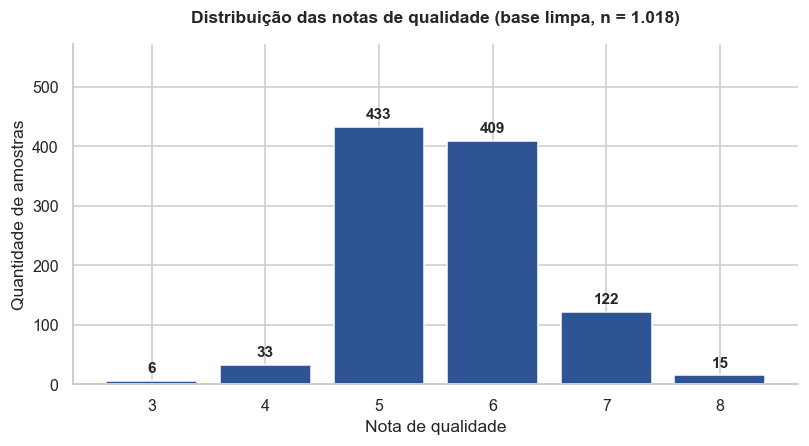

Notas 5+6 = 842 (83% da base).


In [ ]:
# >>> 2.2 — distribuição da nota (Figura 1)
dist = df["quality"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(dist.index.astype(str), dist.values, color=AZUL, edgecolor="white")
ax.set_title("Distribuição das notas de qualidade (base limpa, n = 1.018)", pad=14)
ax.set_xlabel("Nota de qualidade"); ax.set_ylabel("Quantidade de amostras")
anota_vertical(ax, dist.values); plt.tight_layout(); plt.show()
print(f"Notas 5+6 = {int(dist.get(5,0)+dist.get(6,0))} ({(dist.get(5,0)+dist.get(6,0))/len(df):.0%} da base).")

**2.3 Balanceamento** ✅ *(gráfico revisado — sem colisão de rótulos).* Com **corte ≥ 7** a base desequilibra (137 × 881): um modelo que sempre chuta "Baixa/Média" acerta **86,5%** *sem achar nenhum vinho bom* — a **armadilha da acurácia**. Solução em dois níveis: o **corte ≥ 6** equilibra na origem (≈54/46); para o ≥ 7, usa-se `class_weight='balanced'` (4.2).

> **Correção estética:** antes os rótulos colidiam com o título do subgráfico. Resolvido com **folga no eixo Y + `pad` no título**.

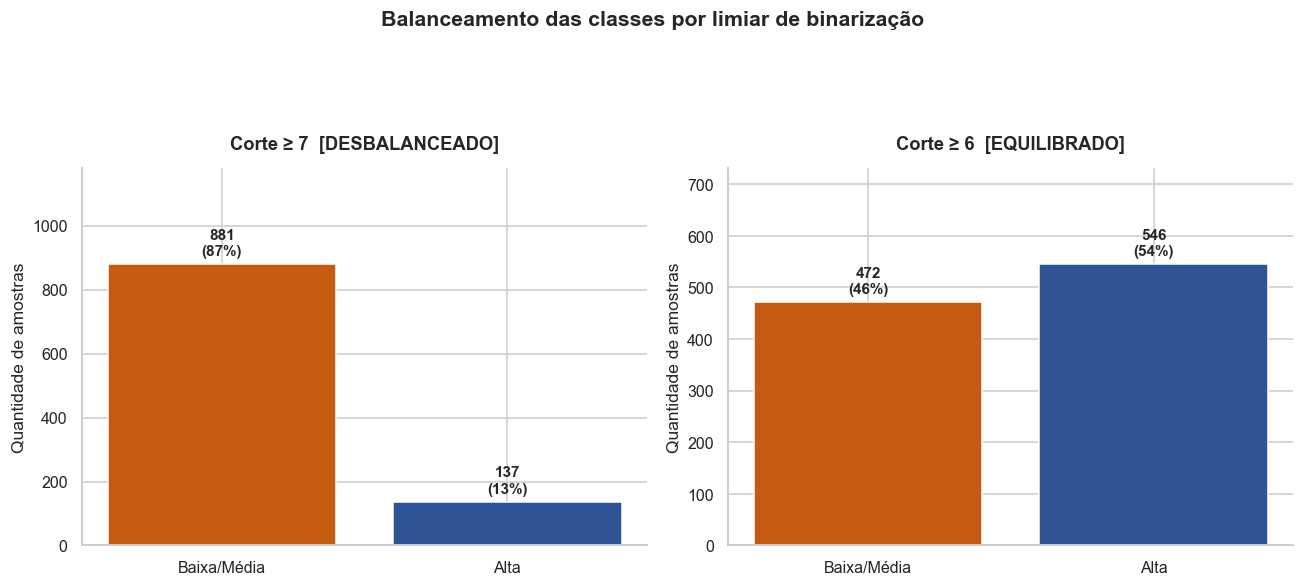

Corte ≥ 7: Baixa/Média=881 (87%) | Alta=137 (13%) | razão 6.4:1
Corte ≥ 6: Baixa/Média=472 (46%) | Alta=546 (54%) | razão 0.9:1


In [ ]:
# >>> 2.3 — balanceamento por limiar (Figura 2, REVISADA)
n = len(df)
fig, eixos = plt.subplots(1, 2, figsize=(12, 5.2))
fig.suptitle("Balanceamento das classes por limiar de binarização", fontsize=14, fontweight="bold", y=1.02)
for ax, (corte, sit) in zip(eixos, [(7, "DESBALANCEADO"), (6, "EQUILIBRADO")]):
    y = (df["quality"] >= corte).astype(int); alt = [int((y==0).sum()), int((y==1).sum())]
    ax.bar(["Baixa/Média", "Alta"], alt, color=[LARANJA, AZUL], edgecolor="white")
    ax.set_title(f"Corte ≥ {corte}  [{sit}]", fontsize=12, pad=12)
    ax.set_ylabel("Quantidade de amostras"); anota_vertical(ax, alt, total=n, folga=0.34)
fig.tight_layout(rect=[0, 0, 1, 0.90]); plt.show()
for corte in (7, 6):
    y = (df["quality"] >= corte).astype(int); ng, ps = int((y==0).sum()), int((y==1).sum())
    print(f"Corte ≥ {corte}: Baixa/Média={ng} ({ng/n:.0%}) | Alta={ps} ({ps/n:.0%}) | razão {ng/ps:.1f}:1")

**2.4 Distribuição das variáveis.** Álcool quase simétrico; **acidez volátil, cloretos e açúcar residual** assimétricos à direita; **ácido cítrico** levemente bimodal. Modelos lineares são, *em princípio*, mais sensíveis a assimetria — ponto **testado empiricamente na Seção 3.3c** (transformação log), onde mostramos que a assimetria **não** é o gargalo aqui.

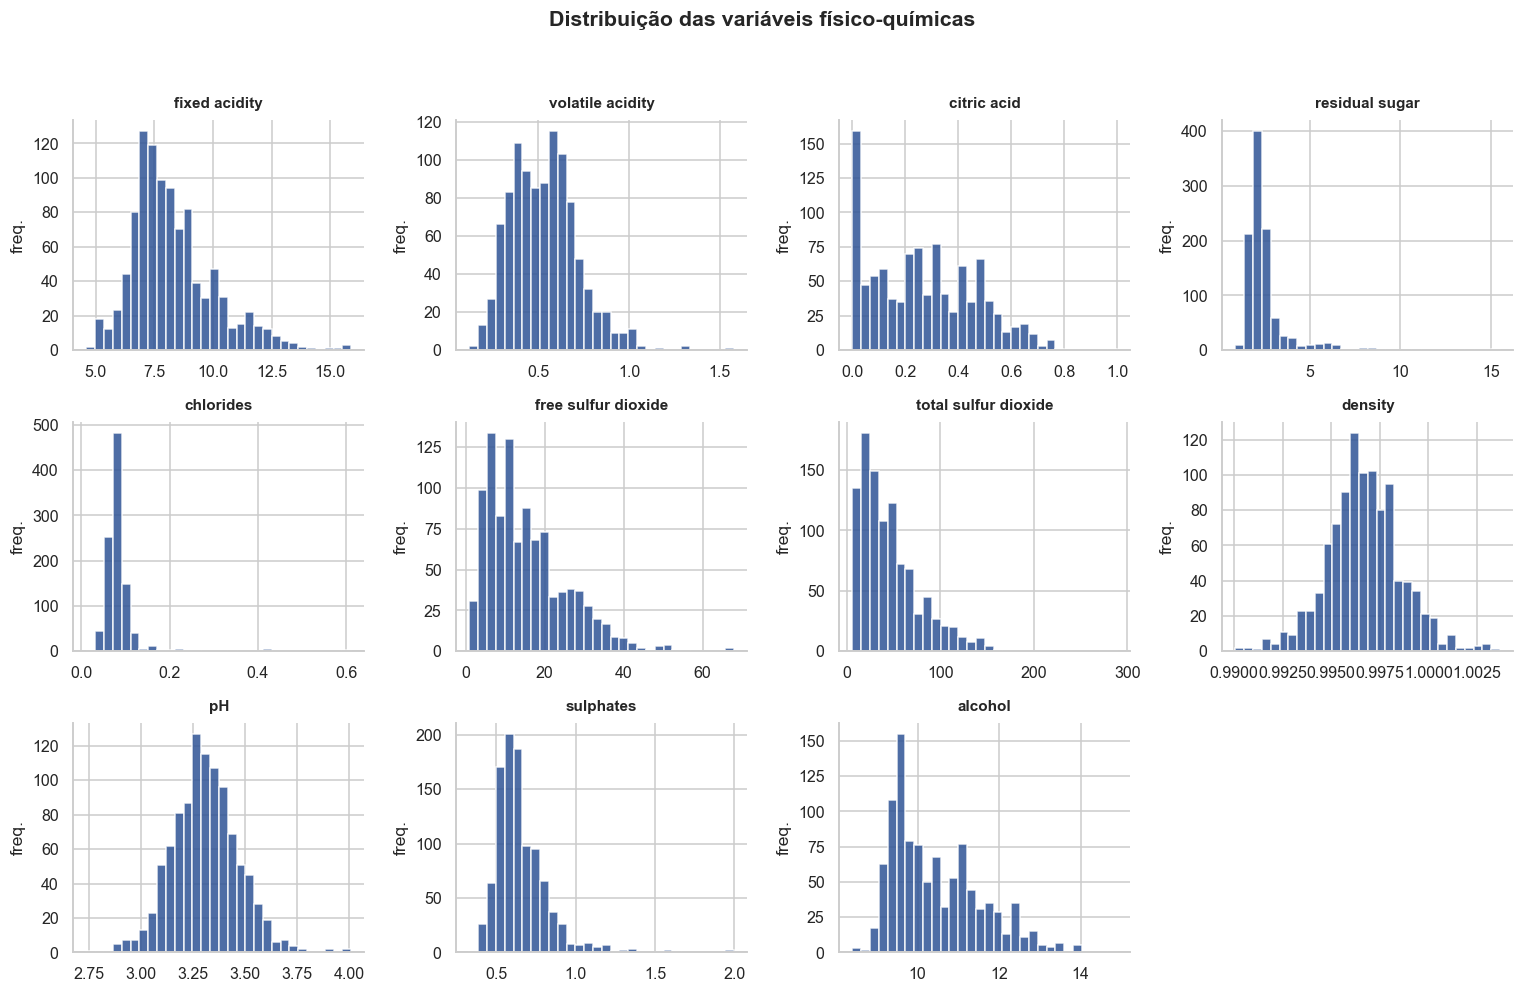

In [ ]:
# >>> 2.4 — histogramas (Figura 3)
fig, axs = plt.subplots(3, 4, figsize=(14, 9))
for ax, col in zip(axs.ravel(), variaveis):
    ax.hist(df[col], bins=30, color=AZUL, edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10, pad=8); ax.set_ylabel("freq.")
for ax in axs.ravel()[len(variaveis):]: ax.set_visible(False)
fig.suptitle("Distribuição das variáveis físico-químicas", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

**2.5 Outliers (IQR).** Mais *outliers*: **açúcar residual (95; 9,3%)**, **cloretos (71; 7,0%)**, **sulfatos (41; 4,0%)**. **Decisão documentada: mantê-los** — valores fisicamente plausíveis, árvores robustas a outliers e padronização atenua o efeito na Regressão Logística.

In [ ]:
# >>> 2.5 — outliers por variável (IQR) + boxplots dos 3 principais (Figura 4)
def out_iqr(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); i = q3-q1
    return int(((s < q1-1.5*i) | (s > q3+1.5*i)).sum())
tab_out = pd.Series({c: out_iqr(df[c]) for c in variaveis}).sort_values(ascending=False).to_frame("qtd_outliers")
tab_out["%_da_base"] = (tab_out["qtd_outliers"]/len(df)*100).round(1)
print(pt(tab_out).to_string())
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axs, tab_out.index[:3]):
    ax.boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor=AZUL, alpha=.6))
    ax.set_title(col, fontsize=11, pad=10); ax.set_xticks([]); eixo_virgula(ax, "y", 2)
fig.suptitle("Boxplots das variáveis com mais outliers (mantidos na base)", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

NameError: name 'variaveis' is not defined

**2.6 Correlações.** *Correlação ≠ causalidade.* **Com a qualidade:** álcool **+0,486** (mais forte), acidez volátil **−0,409** (mais negativa), sulfatos **+0,258**, ácido cítrico **+0,242**, densidade **−0,185**.
**Entre variáveis (mapa comentado):** acidez fixa ↔ densidade **+0,67**, ácido cítrico **+0,67**, pH **−0,69** (esqueleto ácido); álcool ↔ densidade **−0,50**; SO₂ livre ↔ total **+0,66**. Esses blocos antecipam **multicolinearidade** (Seção 2.8) e mostram por que Pearson não capta interações não lineares (vistas pela floresta e pelo SHAP, Seção 7).

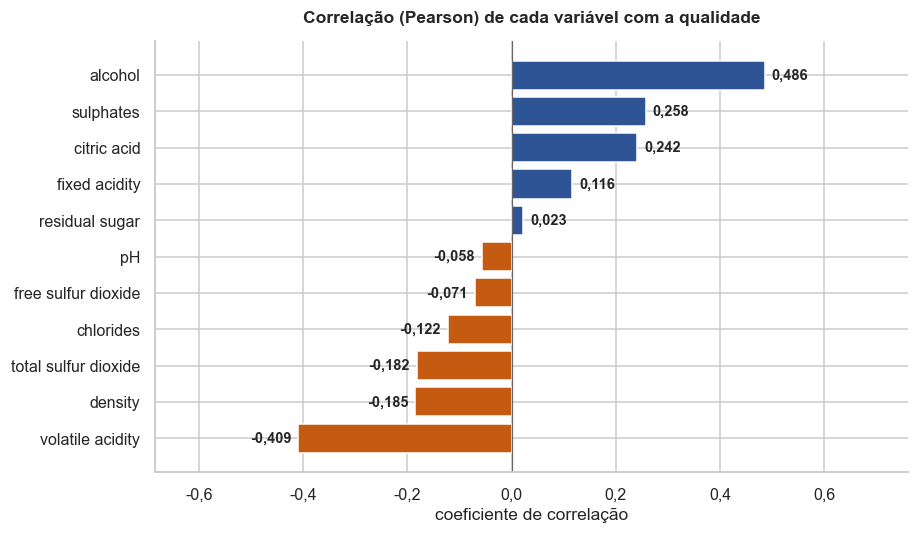

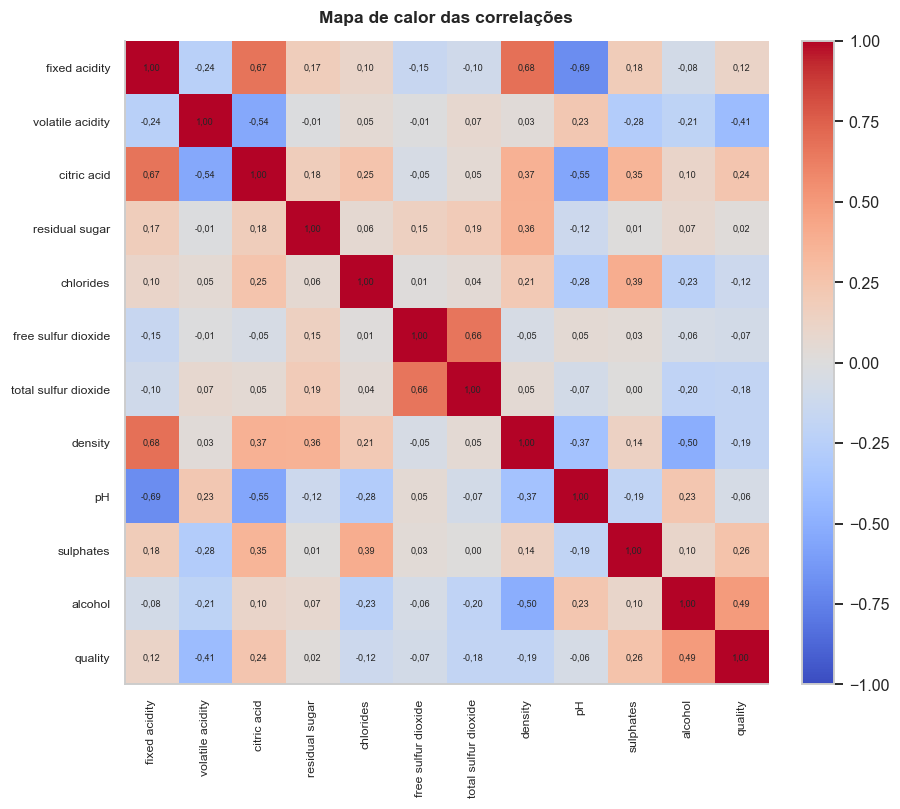

In [ ]:
# >>> 2.6 — correlação com a qualidade (Figura 5) + mapa de calor (Figura 6)
corr_q = df[variaveis+["quality"]].corr()["quality"].drop("quality").sort_values()
fig, ax = plt.subplots(figsize=(8.5, 5))
barh_signed(ax, list(corr_q.index), list(corr_q.values), dec=3, folga=0.14)
ax.set_title("Correlação (Pearson) de cada variável com a qualidade", pad=12)
ax.set_xlabel("coeficiente de correlação"); eixo_virgula(ax, "x", 1); plt.tight_layout(); plt.show()

mat = df[variaveis+["quality"]].corr()
fig, ax = plt.subplots(figsize=(9, 7.5)); im = ax.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(mat))); ax.set_xticklabels(mat.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(mat))); ax.set_yticklabels(mat.columns, fontsize=8)
for i in range(len(mat)):
    for j in range(len(mat)):
        ax.text(j, i, f"{mat.iloc[i,j]:.2f}".replace(".", ","), ha="center", va="center", fontsize=6)
ax.set_title("Mapa de calor das correlações", pad=12); ax.grid(False)
fig.colorbar(im, fraction=.046, pad=.04); plt.tight_layout(); plt.show()

**2.7 Poder discriminante por classe (novo).** Comparando cada variável-chave **entre as classes** (corte ≥ 6): a classe **Alta** tem **álcool** e **sulfatos** maiores e **acidez volátil** e **SO₂ total** menores — a tradução gráfica do que os modelos exploram.

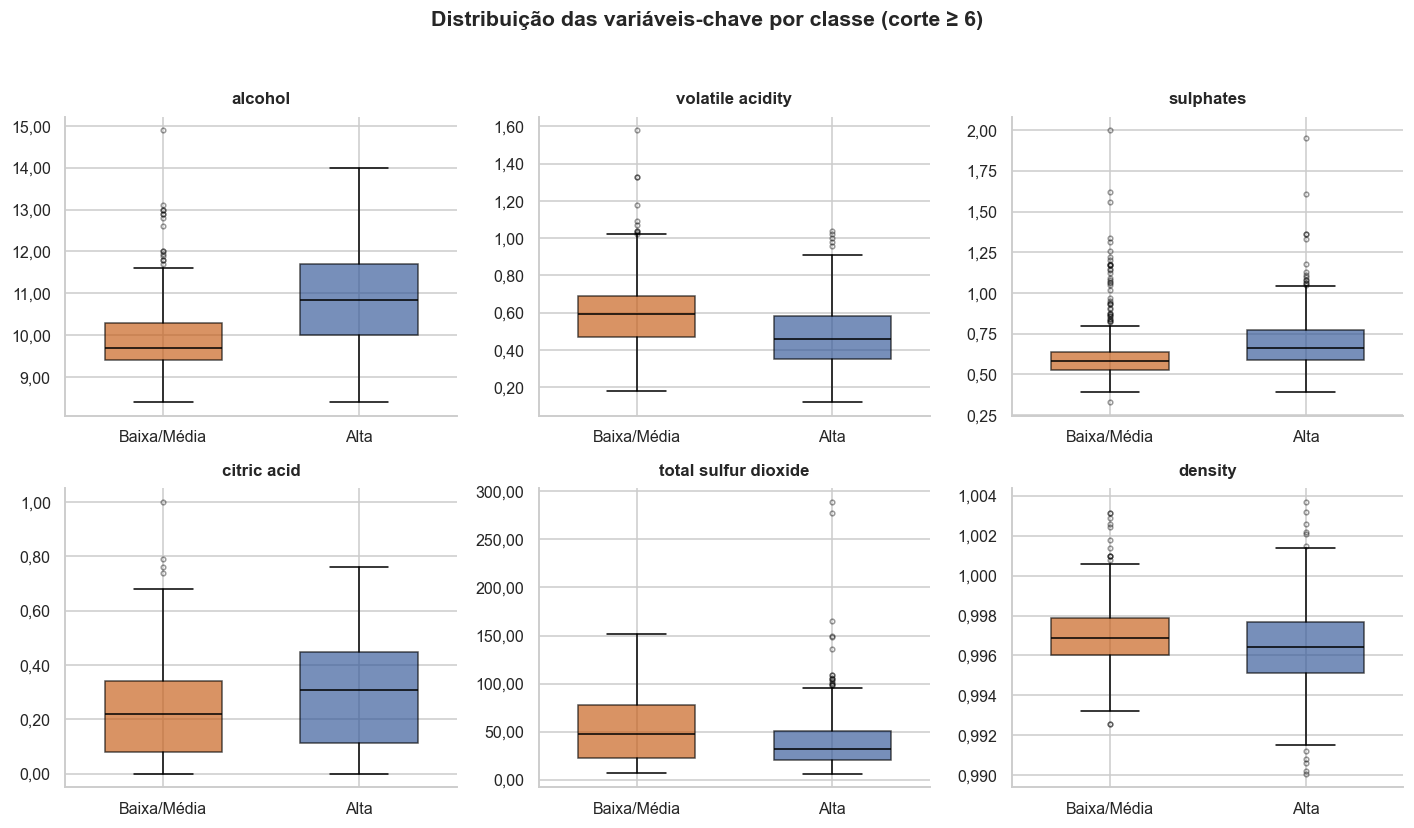

In [ ]:
# >>> 2.7 — boxplots por classe (Figura A)
y6f = (df["quality"] >= 6).astype(int)
feat = ["alcohol", "volatile acidity", "sulphates", "citric acid", "total sulfur dioxide", "density"]
fig, axs = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, col in zip(axs.ravel(), feat):
    bp = ax.boxplot([df.loc[y6f==0, col], df.loc[y6f==1, col]], vert=True, patch_artist=True,
                    widths=.6, tick_labels=["Baixa/Média", "Alta"], flierprops=dict(marker="o", markersize=3, alpha=.4))
    for p, c in zip(bp["boxes"], [LARANJA, AZUL]): p.set_facecolor(c); p.set_alpha(.65)
    for m in bp["medians"]: m.set_color("black")
    ax.set_title(col, fontsize=11, pad=8); eixo_virgula(ax, "y", 3 if col == "density" else 2)
fig.suptitle("Distribuição das variáveis-chave por classe (corte ≥ 6)", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

**2.8 Multicolinearidade — VIF (novo).** O **VIF** mede o quanto a variância de um coeficiente é inflada pela correlação com as demais (regra: **>5** = atenção; **>10** = severo). **Acidez fixa (≈8,0)** e **densidade (≈6,6)** passam de 5 — coerente com o mapa de calor. **Implicação:** os *coeficientes* dessas duas variáveis na Regressão Logística pedem cautela; o **poder preditivo** não é afetado. As dominantes (álcool, sulfatos, acidez volátil) têm VIF baixo → interpretação estável.

In [ ]:
# >>> 2.8 — Fator de Inflação de Variância (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = df[variaveis].copy(); Xv = (Xv-Xv.mean())/Xv.std(); Xv["_const"] = 1.0
vif = pd.Series({c: variance_inflation_factor(Xv.values, k) for k, c in enumerate(variaveis)}).sort_values(ascending=False)
print("VIF por variável (>5 = atenção):"); print(pt(vif).round(2).to_string())

VIF por variável (>5 = atenção):
Acidez fixa                 7.97
Densidade                   6.62
pH                          3.48
Teor alcoólico              3.29
Ácido cítrico               3.24
Dióxido de enxofre total    2.12
Dióxido de enxofre livre    1.89
Acidez volátil              1.77
Açúcar residual             1.71
Cloretos                    1.58
Sulfatos                    1.47


## 3. Pré-Processamento de Dados
Modular, auditável e **livre de vazamento**. **3.1** sem nulos → sem imputação. **3.2** 125 idênticos removidos (`Id` ignorado) → 1.018. **3.4** padronização **dentro do pipeline**. **3.5** split **80/20 estratificado** → 814/204.

**3.3a Engenharia (criada, testada e descartada).** Testamos a **razão SO₂ livre/total** (hipótese: fração ativa do conservante), comparando o F1 (CV) com e sem a variável.

In [ ]:
# >>> 3 — base comum de validação cruzada e teste do so2_ratio (Tabela 2)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y6 = (df["quality"] >= 6).astype(int); X_base = df[variaveis]
def f1cv(X, est): return cross_val_score(Pipeline([("sc", StandardScaler()), ("clf", est)]), X, y6, scoring="f1", cv=cv)

X_eng = X_base.assign(so2_ratio=df["free sulfur dioxide"]/df["total sulfur dioxide"].replace(0, np.nan)).fillna(0)
print("Tabela 2 — efeito do so2_ratio (F1 em validação cruzada):")
for nome, est in [("Regressão Logística", LogisticRegression(max_iter=2000, random_state=SEED)),
                  ("Random Forest", RandomForestClassifier(random_state=SEED))]:
    b, e = f1cv(X_base, est), f1cv(X_eng, est)
    print(f"  {nome:22s} sem={br(b.mean(),4)} com={br(e.mean(),4)} Δ={br(e.mean()-b.mean(),4)} (±{br(b.std(),3)})")
print("→ Δ desprezível (< desvio entre dobras) e SO₂ livre/total já estão no modelo: DESCARTADA.")

Tabela 2 — efeito do so2_ratio (F1 em validação cruzada):
  Regressão Logística    sem=0,7603 com=0,7589 Δ=-0,0014 (±0,028)


  Random Forest          sem=0,7609 com=0,7684 Δ=0,0076 (±0,021)
→ Δ desprezível (< desvio entre dobras) e SO₂ livre/total já estão no modelo: DESCARTADA.


**3.3b Interações (novo).** Para demonstrar exploração, testamos três interações sugeridas em revisão — **álcool×sulfatos**, **álcool/densidade**, **acidez volátil×sulfatos** — comparando o F1 (CV). Esperado: ganho nulo, pois as árvores já capturam interações implicitamente.

In [ ]:
# >>> 3.3b — interações (Tabela 2b)
X_int = X_base.assign(alc_x_sulf=df["alcohol"]*df["sulphates"],
                      alc_div_dens=df["alcohol"]/df["density"],
                      va_x_sulf=df["volatile acidity"]*df["sulphates"])
print("Tabela 2b — efeito das interações (F1 em validação cruzada):")
for nome, est in [("Regressão Logística", LogisticRegression(max_iter=2000, random_state=SEED)),
                  ("Random Forest", RandomForestClassifier(random_state=SEED))]:
    b, e = f1cv(X_base, est), f1cv(X_int, est)
    print(f"  {nome:22s} sem={br(b.mean(),4)} com={br(e.mean(),4)} Δ={br(e.mean()-b.mean(),4)} (±{br(b.std(),3)})")
print("→ Variação dentro do ruído: interações NÃO incorporadas (exploração documentada).")

Tabela 2b — efeito das interações (F1 em validação cruzada):
  Regressão Logística    sem=0,7603 com=0,7557 Δ=-0,0045 (±0,028)


  Random Forest          sem=0,7609 com=0,7646 Δ=0,0037 (±0,021)
→ Variação dentro do ruído: interações NÃO incorporadas (exploração documentada).


**3.3c Robustez a distribuições assimétricas — teste log (novo).** Fecha o ponto da Seção 2.4: aplicamos **log1p** às variáveis assimétricas (açúcar residual, cloretos, SO₂ livre/total, sulfatos) e recomparamos o F1 da Regressão Logística. **Conclusão antecipada:** ΔF1 ≈ ruído → a assimetria **não** é o gargalo. Motivo: *assimetria ≠ não linearidade*; após **padronização** (e regularização L2), a relação monotônica das variáveis dominantes é bem capturada por um modelo linear.

In [ ]:
# >>> 3.3c — transformação log nas assimétricas (Tabela log)
skew = ["residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "sulphates"]
X_log = X_base.copy()
for c in skew: X_log[c] = np.log1p(X_log[c])
b, e = f1cv(X_base, LogisticRegression(max_iter=2000, random_state=SEED)), f1cv(X_log, LogisticRegression(max_iter=2000, random_state=SEED))
print(f"Regressão Logística — F1(CV) sem log = {br(b.mean(),4)} | com log = {br(e.mean(),4)} | Δ = {br(e.mean()-b.mean(),4)} (±{br(b.std(),3)})")
print("→ Δ desprezível: a assimetria das marginais NÃO limita o modelo linear neste problema.")

Regressão Logística — F1(CV) sem log = 0,7603 | com log = 0,7615 | Δ = 0,0013 (±0,028)
→ Δ desprezível: a assimetria das marginais NÃO limita o modelo linear neste problema.


In [ ]:
# >>> 3.5 — divisão treino/teste estratificada (usada em todo o estudo)
FEATURES = list(variaveis)
def separar(corte):
    y = (df["quality"] >= corte).astype(int)
    return train_test_split(df[FEATURES], y, test_size=.20, random_state=SEED, stratify=y)
X_tr6, X_te6, y_tr6, y_te6 = separar(6)
X_tr7, X_te7, y_tr7, y_te7 = separar(7)
print(f"Corte ≥ 6 → treino {len(X_tr6)} | teste {len(X_te6)} | %Alta teste = {y_te6.mean():.3f}")

Corte ≥ 6 → treino 814 | teste 204 | %Alta teste = 0.534


## 4. Desenvolvimento de Modelos
**4.1** Sete algoritmos **efetivamente treinados** sob o mesmo protocolo (pipeline com padronização): Regressão Logística, Random Forest, SVM, KNN, Gradient Boosting, Árvore de Decisão e Naive Bayes.
**4.2** No corte ≥ 7, os que suportam recebem `class_weight='balanced'` (SMOTE/undersampling avaliados e descartados — base pequena).

In [ ]:
# >>> 4.1 — fábrica dos 7 modelos (pipeline com padronização) + avaliação reutilizável
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve,
                             precision_recall_curve, average_precision_score)
def construir(balanced=False):
    cw = "balanced" if balanced else None
    est = {"Regressão Logística": LogisticRegression(max_iter=2000, random_state=SEED, class_weight=cw),
           "Random Forest": RandomForestClassifier(random_state=SEED, class_weight=cw),
           "SVM": SVC(probability=True, random_state=SEED, class_weight=cw),
           "KNN": KNeighborsClassifier(),
           "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
           "Árvore de Decisão": DecisionTreeClassifier(random_state=SEED, class_weight=cw),
           "Naive Bayes": GaussianNB()}
    return {k: Pipeline([("sc", StandardScaler()), ("clf", v)]) for k, v in est.items()}
def avaliar(modelos, Xtr, ytr, Xte, yte):
    L = {}
    for nome, pipe in modelos.items():
        pipe.fit(Xtr, ytr); pred = pipe.predict(Xte)
        try: auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])
        except Exception: auc = np.nan
        L[nome] = {"Acurácia": accuracy_score(yte, pred), "Precisão": precision_score(yte, pred, zero_division=0),
                   "Recall": recall_score(yte, pred), "F1": f1_score(yte, pred), "ROC-AUC": auc}
    return pd.DataFrame(L).T.sort_values("F1", ascending=False).round(4)
def grafico_f1(tab, titulo):
    o = tab.sort_values("F1"); cores = [AZUL]*len(o); cores[-1] = LARANJA
    fig, ax = plt.subplots(figsize=(9, 4.5)); ax.barh(o.index, o["F1"], color=cores, edgecolor="white")
    ax.set_title(titulo, pad=12); ax.set_xlabel("F1-Score (teste)"); anota_h_pos(ax, o["F1"].values, dec=3)
    eixo_virgula(ax, "x", 1); plt.tight_layout(); plt.show()
print("Modelos:", ", ".join(construir().keys()))

Modelos: Regressão Logística, Random Forest, SVM, KNN, Gradient Boosting, Árvore de Decisão, Naive Bayes


**4.3 Otimização de hiperparâmetros.** **GridSearchCV** (5 dobras, F1) aplicado aos dois modelos principais **sobre o conjunto de treino do corte ≥ 6**. Esclarecimento importante: as **Tabelas 4–7 reportam os modelos *default*** (configuração de fábrica); o GridSearch entrega os modelos **otimizados** usados na interpretabilidade (Seção 7) e na recomendação final. O F1 de validação é levemente superior ao de teste (otimismo natural em base de ~mil amostras), sem superajuste relevante.

In [ ]:
# >>> 4.3 — GridSearchCV (Regressão Logística e Random Forest) sobre o treino do corte ≥ 6 (Tabela 3)
from sklearn.model_selection import GridSearchCV
grade_lr = GridSearchCV(Pipeline([("sc", StandardScaler()),
                ("clf", LogisticRegression(max_iter=3000, random_state=SEED, solver="liblinear"))]),
                {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}, scoring="f1", cv=cv, n_jobs=-1).fit(X_tr6, y_tr6)
grade_rf = GridSearchCV(Pipeline([("sc", StandardScaler()), ("clf", RandomForestClassifier(random_state=SEED))]),
                {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 6, 10], "clf__min_samples_leaf": [1, 2, 5]},
                scoring="f1", cv=cv, n_jobs=-1).fit(X_tr6, y_tr6)
rf_tunado = grade_rf.best_estimator_
print(f"Regressão Logística → {grade_lr.best_params_} | F1(CV) = {br(grade_lr.best_score_,4)}")
print(f"Random Forest       → {grade_rf.best_params_} | F1(CV) = {br(grade_rf.best_score_,4)}")
print(f"Random Forest otimizada — F1(teste) = {br(f1_score(y_te6, rf_tunado.fit(X_tr6,y_tr6).predict(X_te6)),4)}")

Regressão Logística → {'clf__C': 0.1, 'clf__penalty': 'l2'} | F1(CV) = 0,7564
Random Forest       → {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400} | F1(CV) = 0,7696


Random Forest otimizada — F1(teste) = 0,7733


## 5. Avaliação — Parte I (corte ≥ 7, desbalanceado)
Finalidade **demonstrativa**: por que a **acurácia engana** e qual o efeito do `class_weight='balanced'`.

**5.1 Sem correção.** Vários modelos exibem **acurácia alta** (SVM 0,897; Regressão Logística 0,887) que apenas reflete a classe majoritária — o **recall** da classe "Alta" é baixíssimo (SVM **0,333**: escapam 2 em cada 3 vinhos excelentes). A acurácia de 0,897 mal supera o palpite ingênuo de **0,865**. O melhor F1 (Naive Bayes, **0,529**) já mostra a dificuldade.

,Acurácia,Precisão,Recall,F1,ROC-AUC
Naive Bayes,0.8431,0.4390,0.6667,0.5294,0.8881
Regressão Logística,0.8873,0.6000,0.4444,0.5106,0.8994
KNN,0.8824,0.5789,0.4074,0.4783,0.8226
SVM,0.8971,0.7500,0.3333,0.4615,0.9186
Gradient Boosting,0.8578,0.4545,0.3704,0.4082,0.8939
Random Forest,0.8676,0.5000,0.2963,0.3721,0.8987
Árvore de Decisão,0.8088,0.3125,0.3704,0.3390,0.6230


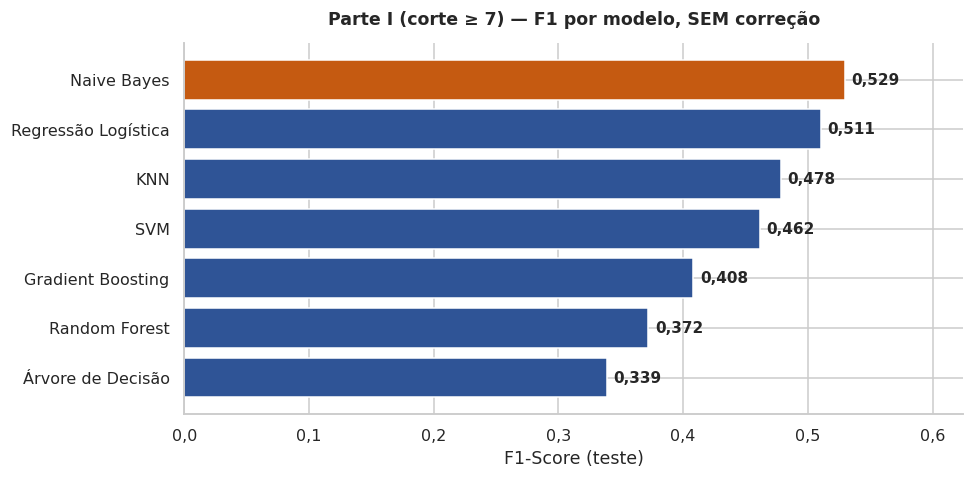

In [ ]:
# >>> 5.1 — Parte I SEM correção (Tabela 4, Figura 7)
tab7 = avaliar(construir(False), X_tr7, y_tr7, X_te7, y_te7)
display(tab7); grafico_f1(tab7, "Parte I (corte ≥ 7) — F1 por modelo, SEM correção")

**5.2 Com `class_weight='balanced'`.** O quadro muda: **SVM** (F1 0,568) e **Regressão Logística** (0,539) passam a **recuperar a maioria** dos vinhos bons (recall **0,93** e **0,89**), ao custo de precisão e acurácia — *exatamente o trade-off desejado*. Ainda assim o F1 máximo (~0,57) confirma que o **corte ≥ 7 é intrinsecamente difícil** — o que motiva a Parte II.

,Acurácia,Precisão,Recall,F1,ROC-AUC
SVM,0.8137,0.4098,0.9259,0.5682,0.9079
Regressão Logística,0.7990,0.3871,0.8889,0.5393,0.9002
Naive Bayes,0.8431,0.4390,0.6667,0.5294,0.8881
Árvore de Decisão,0.8431,0.4324,0.5926,0.5000,0.7370
KNN,0.8824,0.5789,0.4074,0.4783,0.8226
Gradient Boosting,0.8578,0.4545,0.3704,0.4082,0.8939
Random Forest,0.8824,0.6154,0.2963,0.4000,0.9180


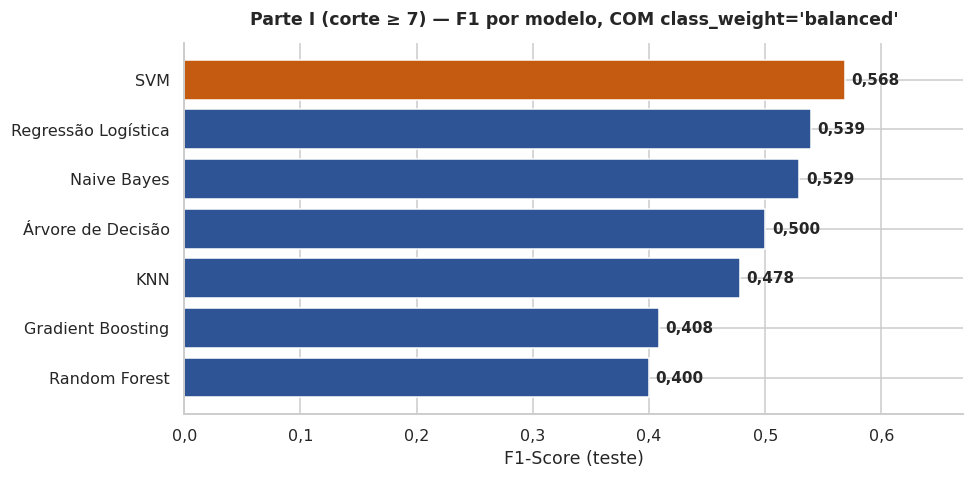

In [ ]:
# >>> 5.2 — Parte I COM class_weight='balanced' (Tabela 5, Figura 8)
tab7b = avaliar(construir(True), X_tr7, y_tr7, X_te7, y_te7)
display(tab7b); grafico_f1(tab7b, "Parte I (corte ≥ 7) — F1 por modelo, COM class_weight='balanced'")

## 6. Avaliação — Parte II (corte ≥ 6, equilibrado)
**6.1 Comparação.** No cenário equilibrado os números tornam-se **confiáveis**. No teste, **Gradient Boosting (0,789)**, **SVM (0,784)**, **Random Forest (0,768)** e **Regressão Logística (0,758)** ficam próximos. Em **validação cruzada**, a **Random Forest tem o melhor F1 médio (0,762) e o menor desvio (±0,015)** — ou seja, é a **mais robusta e a mais estável** entre execuções; a Regressão Logística e o Gradient Boosting vêm logo atrás. A proximidade indica que o teto vem da **dificuldade do problema**, não do algoritmo (confirmado estatisticamente na Seção 6.4).

,Acurácia,Precisão,Recall,F1,ROC-AUC
Gradient Boosting,0.7647,0.7563,0.8257,0.7895,0.8255
SVM,0.7647,0.7699,0.7982,0.7838,0.8173
Random Forest,0.7451,0.7478,0.7890,0.7679,0.8028
Regressão Logística,0.7304,0.7288,0.7890,0.7577,0.8080
KNN,0.7157,0.7179,0.7706,0.7434,0.7558
Naive Bayes,0.7206,0.7364,0.7431,0.7397,0.7794
Árvore de Decisão,0.6863,0.7027,0.7156,0.7091,0.6841


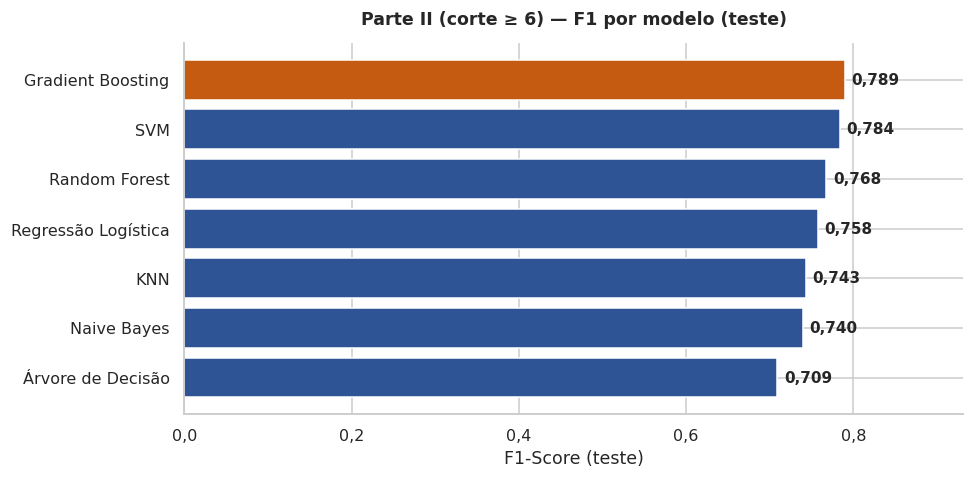

Tabela 7 — estabilidade (F1 em validação cruzada, 5 dobras):
  Regressão Logística    F1 = 0,7547 ± 0,021


  Random Forest          F1 = 0,7623 ± 0,015


  SVM                    F1 = 0,7488 ± 0,021
  KNN                    F1 = 0,7220 ± 0,029


  Gradient Boosting      F1 = 0,7555 ± 0,017
  Árvore de Decisão      F1 = 0,6882 ± 0,020
  Naive Bayes            F1 = 0,7502 ± 0,020


In [ ]:
# >>> 6.1 — comparação dos 7 modelos (Tabela 6, Figura 9) + estabilidade por CV (Tabela 7)
tab6 = avaliar(construir(False), X_tr6, y_tr6, X_te6, y_te6)
display(tab6); grafico_f1(tab6, "Parte II (corte ≥ 6) — F1 por modelo (teste)")
print("Tabela 7 — estabilidade (F1 em validação cruzada, 5 dobras):")
for nome, pipe in construir(False).items():
    sc = cross_val_score(pipe, X_tr6, y_tr6, scoring="f1", cv=cv)
    print(f"  {nome:22s} F1 = {br(sc.mean(),4)} ± {br(sc.std(),3)}")

**6.2 Trade-off entre os dois erros (negócio).** **Falso positivo** (prever "Alta" para vinho comum) → produto premium aquém, risco de devolução; pede **maior precisão** (SVM 0,770; Gradient Boosting 0,756). **Falso negativo** (prever "Baixa/Média" para vinho excelente) → **perda de receita**; pede **maior recall** (Gradient Boosting 0,826; SVM/Regressão Logística 0,80/0,79). A matriz de confusão contrasta o **modelo recomendado (Random Forest)** com o **líder de F1 no teste (Gradient Boosting)**.

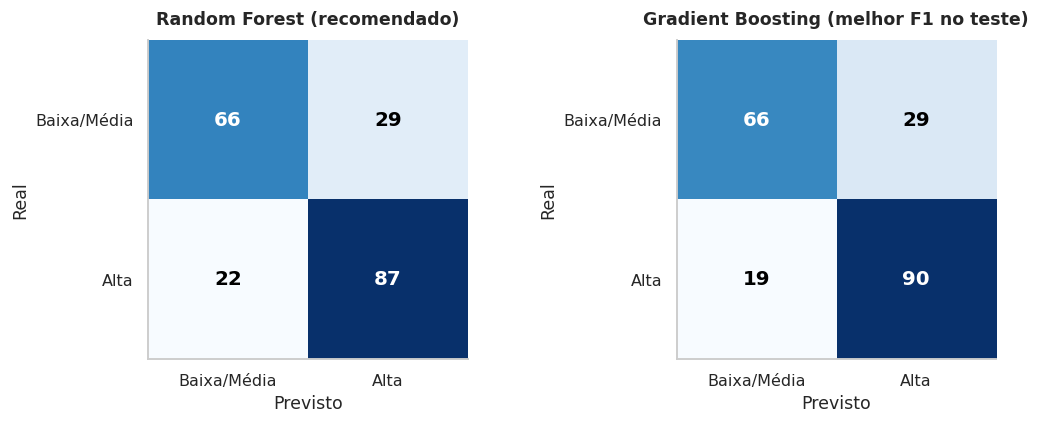

In [ ]:
# >>> 6.2 — matrizes de confusão: recomendado (RF otimizada) x melhor F1 (GB) (Figura 10)
def cm_ax(ax, pred, titulo):
    cm = confusion_matrix(y_te6, pred); ax.imshow(cm, cmap="Blues"); ax.set_title(titulo, pad=10); ax.grid(False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Baixa/Média", "Alta"]); ax.set_yticks([0, 1]); ax.set_yticklabels(["Baixa/Média", "Alta"])
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); lim = cm.max()/2
    for i in range(2):
        for j in range(2): ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13, fontweight="bold", color="white" if cm[i, j] > lim else "black")
pred_rf = rf_tunado.fit(X_tr6, y_tr6).predict(X_te6)
gb = construir(False)["Gradient Boosting"]; pred_gb = gb.fit(X_tr6, y_tr6).predict(X_te6)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
cm_ax(a1, pred_rf, "Random Forest (recomendado)"); cm_ax(a2, pred_gb, "Gradient Boosting (melhor F1 no teste)")
plt.tight_layout(); plt.show()

**6.3 Capacidade de separação (ROC).** A **maior AUC é do Gradient Boosting (0,825)**, seguido por SVM (0,817), Regressão Logística (0,808) e Random Forest (0,803). *(Correção: a versão anterior afirmava que a Regressão Logística tinha a maior AUC — o que contrariava a própria tabela.)* Todos separam bem as classes (AUC ≈ 0,80), mesmo que o limiar-padrão não seja ideal para todo cenário de negócio.

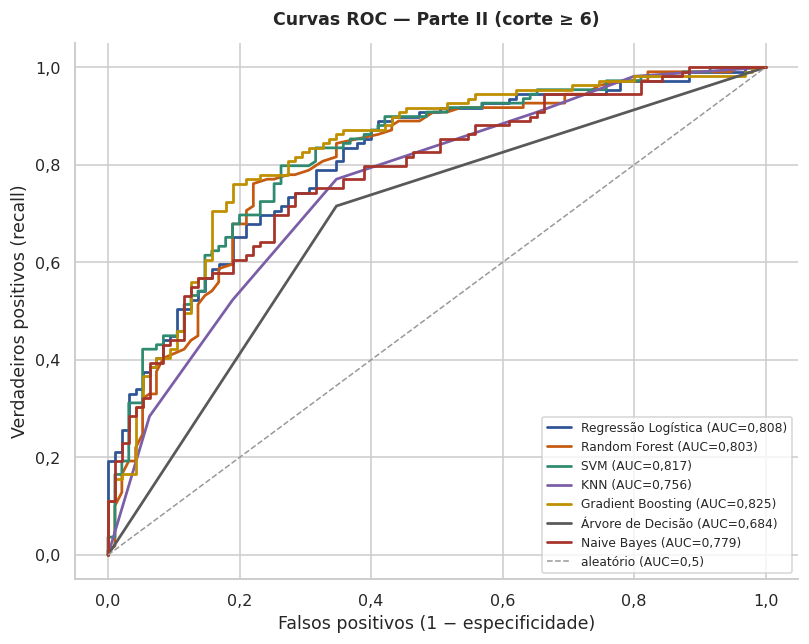

In [ ]:
# >>> 6.3 — curvas ROC (Figura 11)
fig, ax = plt.subplots(figsize=(7.5, 6))
for (nome, pipe), cor in zip(construir(False).items(), PALETA):
    pipe.fit(X_tr6, y_tr6); p = pipe.predict_proba(X_te6)[:, 1]
    fpr, tpr, _ = roc_curve(y_te6, p); ax.plot(fpr, tpr, color=cor, lw=1.8, label=f"{nome} (AUC={br(roc_auc_score(y_te6,p))})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=1, label="aleatório (AUC=0,5)")
ax.set_title("Curvas ROC — Parte II (corte ≥ 6)", pad=12)
ax.set_xlabel("Falsos positivos (1 − especificidade)"); ax.set_ylabel("Verdadeiros positivos (recall)")
eixo_virgula(ax, "x", 1); eixo_virgula(ax, "y", 1); ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

**6.4 Significância estatística e robustez das diferenças (novo).** Para responder "as diferenças entre os melhores modelos são reais?", aplicamos três testes:
1. **McNemar** (sobre acertos/erros pareados no teste): Gradient Boosting × SVM **p = 1,00**; Gradient Boosting × Random Forest **p ≈ 0,82**; Regressão Logística × Random Forest **p ≈ 0,73** — **nenhuma diferença significativa**.
2. **Comparação pareada por dobras** (Random Forest × Regressão Logística): diferença média 0,008, **p ≈ 0,55**.
3. **Bootstrap (IC 95%) do F1 no teste:** os intervalos **se sobrepõem amplamente**.
4. **Curva Precision-Recall (Figura B):** a Regressão Logística tem a maior **Average Precision (0,833)**, com Gradient Boosting (0,831) e SVM (0,824) logo atrás.

**Conclusão:** no topo, os modelos são **estatisticamente indistinguíveis** — a escolha do modelo de produção deve ser feita por **critérios operacionais** (estabilidade, robustez, interpretabilidade), não pelo F1 de uma única partição.

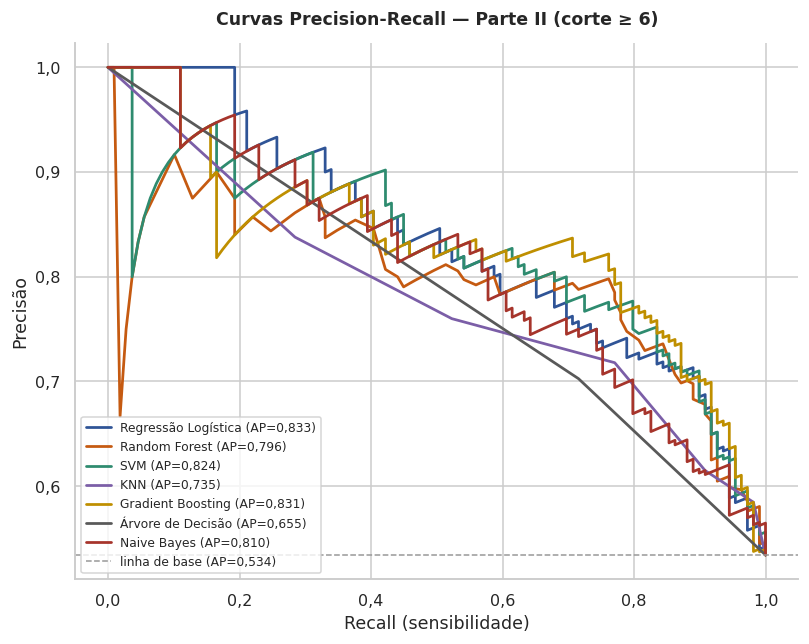

McNemar  GB×SVM p=1,000 | GB×RF p=0,541 | RF×LR p=0,728  → diferenças NÃO significativas


Pareado por dobras RF×LR: Δ=0,0076 | t=0,649 | p=0,552


IC95% F1  Regressão Logística    [0,691 ; 0,816]


IC95% F1  Random Forest          [0,704 ; 0,828]


IC95% F1  Gradient Boosting      [0,726 ; 0,845]


IC95% F1  SVM                    [0,718 ; 0,841]
→ ICs sobrepostos: no topo, os modelos são estatisticamente indistinguíveis.


In [ ]:
# >>> 6.4 — Precision-Recall (Figura B), McNemar, teste pareado por dobras e bootstrap
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats
mods = construir(False); base_rate = float(y_te6.mean())
fig, ax = plt.subplots(figsize=(7.5, 6))
for (nome, pipe), cor in zip(mods.items(), PALETA):
    pipe.fit(X_tr6, y_tr6); p = pipe.predict_proba(X_te6)[:, 1]
    pr, rc, _ = precision_recall_curve(y_te6, p)
    ax.plot(rc, pr, color=cor, lw=1.8, label=f"{nome} (AP={br(average_precision_score(y_te6,p))})")
ax.axhline(base_rate, ls="--", color="0.6", lw=1, label=f"linha de base (AP={br(base_rate)})")
ax.set_title("Curvas Precision-Recall — Parte II (corte ≥ 6)", pad=12)
ax.set_xlabel("Recall (sensibilidade)"); ax.set_ylabel("Precisão")
eixo_virgula(ax, "x", 1); eixo_virgula(ax, "y", 1); ax.legend(fontsize=8, loc="lower left"); plt.tight_layout(); plt.show()

def mcn(a, b):
    ca, cb = (a == y_te6.values), (b == y_te6.values)
    t = [[int(np.sum(ca & cb)), int(np.sum(ca & ~cb))], [int(np.sum(~ca & cb)), int(np.sum(~ca & ~cb))]]
    return mcnemar(t, exact=True).pvalue
pgb = mods["Gradient Boosting"].fit(X_tr6, y_tr6).predict(X_te6)
psvm = mods["SVM"].fit(X_tr6, y_tr6).predict(X_te6)
prf = mods["Random Forest"].fit(X_tr6, y_tr6).predict(X_te6)
plr = mods["Regressão Logística"].fit(X_tr6, y_tr6).predict(X_te6)
print(f"McNemar  GB×SVM p={br(mcn(pgb,psvm),3)} | GB×RF p={br(mcn(pgb,prf),3)} | RF×LR p={br(mcn(prf,plr),3)}  → diferenças NÃO significativas")
f1_rf = cross_val_score(mods["Random Forest"], X_tr6, y_tr6, scoring="f1", cv=cv)
f1_lr = cross_val_score(mods["Regressão Logística"], X_tr6, y_tr6, scoring="f1", cv=cv)
t, p = stats.ttest_rel(f1_rf, f1_lr)
print(f"Pareado por dobras RF×LR: Δ={br(f1_rf.mean()-f1_lr.mean(),4)} | t={br(t,3)} | p={br(p,3)}")
rng = np.random.default_rng(SEED)
def ic(pred):
    y = y_te6.values; idx = np.arange(len(y)); v = [f1_score(y[s], pred[s], zero_division=0) for s in (rng.choice(idx, len(idx), True) for _ in range(3000))]
    return np.percentile(v, [2.5, 97.5])
for nome, pred in [("Regressão Logística", plr), ("Random Forest", prf), ("Gradient Boosting", pgb), ("SVM", psvm)]:
    lo, hi = ic(pred); print(f"IC95% F1  {nome:22s} [{br(lo,3)} ; {br(hi,3)}]")
print("→ ICs sobrepostos: no topo, os modelos são estatisticamente indistinguíveis.")

## 7. Interpretação dos Resultados
**Por que** o modelo decide importa tanto quanto **o quanto** ele acerta. Usamos **três métodos independentes**; sua **convergência** dá robustez. Treinamos uma Random Forest com os melhores hiperparâmetros **sem padronização** (árvores são invariantes à escala).

In [ ]:
# >>> 7 — Random Forest dedicada à interpretabilidade
melhores_rf = {k.replace("clf__", ""): v for k, v in grade_rf.best_params_.items()}
rf_interpret = RandomForestClassifier(random_state=SEED, **melhores_rf).fit(X_tr6, y_tr6)
print("Random Forest (interpretabilidade):", melhores_rf)

Random Forest (interpretabilidade): {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 400}


**7.1 Importância pela Random Forest.** **Teor alcoólico** domina (≈0,20), seguido por **sulfatos**, **acidez volátil** e **SO₂ total**. As de menor contribuição (**açúcar residual, SO₂ livre**) — atenção: o açúcar residual é também o de **mais outliers (9,3%)**, o que pode diluir seu poder; já o SO₂ livre tem **poucos** outliers (1,6%), então sua baixa importância **não** se explica por outliers.

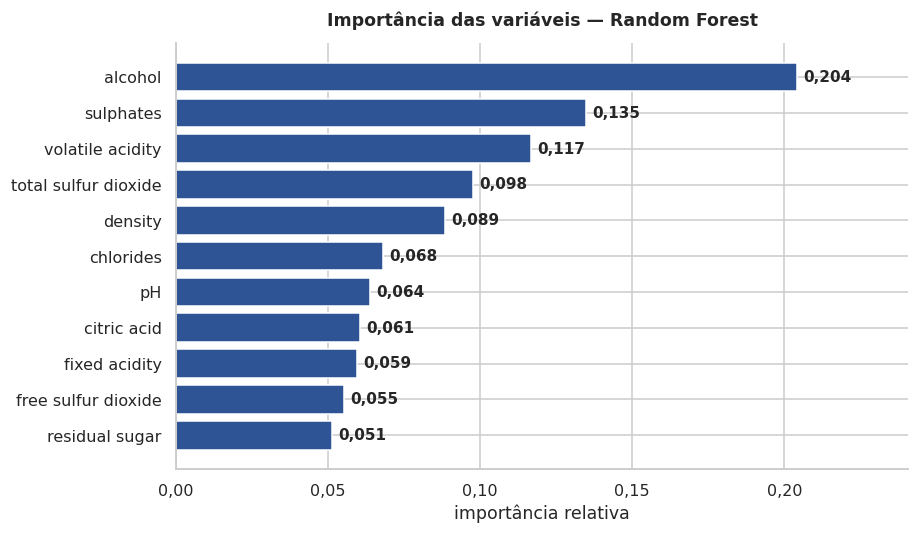

In [ ]:
# >>> 7.1 — importância das variáveis (Figura 12)
imp = pd.Series(rf_interpret.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 5)); ax.barh(imp.index, imp.values, color=AZUL, edgecolor="white")
ax.set_title("Importância das variáveis — Random Forest", pad=12); ax.set_xlabel("importância relativa")
anota_h_pos(ax, imp.values, dec=3); eixo_virgula(ax, "x", 2); plt.tight_layout(); plt.show()

**7.2 SHAP.** Decompõe **cada previsão** (importância + direção + intensidade): **álcool alto** empurra para "Alta"; **acidez volátil alta** empurra para "Baixa/Média"; **sulfatos** têm efeito positivo. O SHAP revela **não linearidades** (ex.: faixa ótima de álcool).

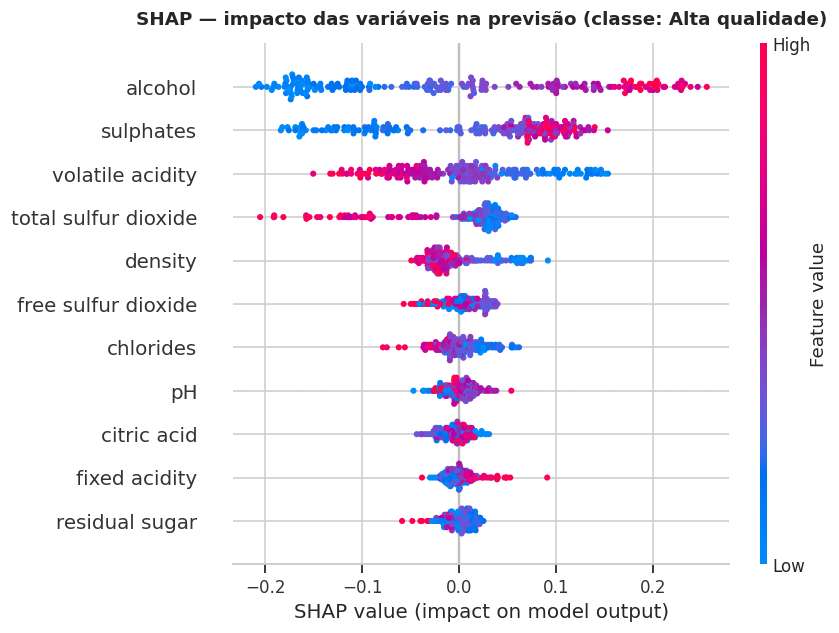

In [ ]:
# >>> 7.2 — SHAP (opcional; degrada com elegância se não instalado) (Figura 13)
try:
    import shap
    expl = shap.TreeExplainer(rf_interpret)(X_te6, check_additivity=False)
    if getattr(expl.values, "ndim", 2) == 3: expl = expl[:, :, 1]
    plt.figure(figsize=(8, 5)); shap.plots.beeswarm(expl, max_display=11, show=False)
    plt.title("SHAP — impacto das variáveis na previsão (classe: Alta qualidade)", fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout(); plt.show()
except ImportError:
    print("Biblioteca 'shap' não instalada — etapa opcional ignorada. (pip install shap)")

**7.3 Importância por permutação** ✅ *(gráfico revisado — rótulos com sinal, sem colisão).* Mede a **queda de F1** ao embaralhar cada variável. **Convergência:** os três métodos (floresta, SHAP, permutação) apontam o **mesmo trio — teor alcoólico, sulfatos e acidez volátil** — tornando o resultado robusto.

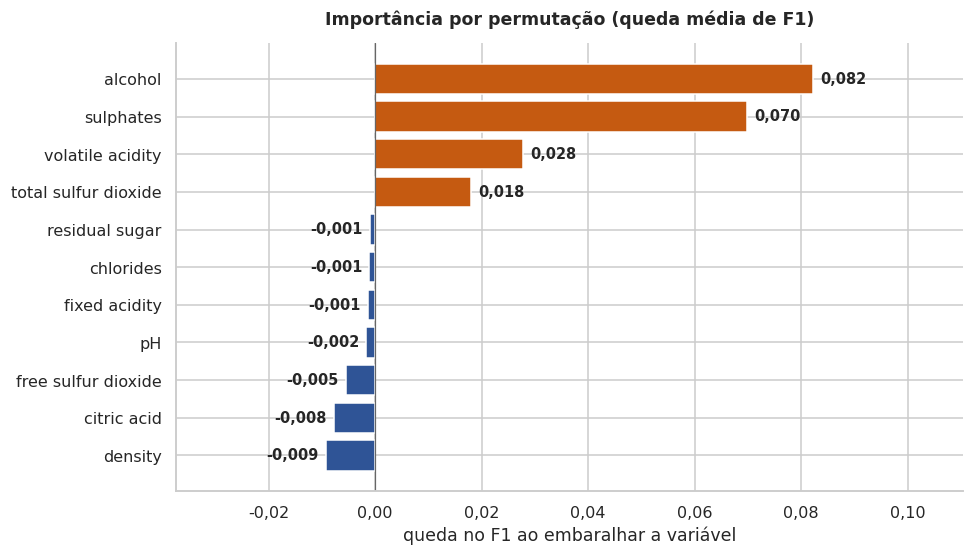

In [ ]:
# >>> 7.3 — importância por permutação (Figura 14, REVISADA: barh_signed)
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf_interpret, X_te6, y_te6, scoring="f1", n_repeats=20, random_state=SEED, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.2))
barh_signed(ax, list(imp_perm.index), list(imp_perm.values), cor_pos=LARANJA, cor_neg=AZUL, dec=3, folga=0.14)
ax.set_title("Importância por permutação (queda média de F1)", pad=12)
ax.set_xlabel("queda no F1 ao embaralhar a variável"); eixo_virgula(ax, "x", 2); plt.tight_layout(); plt.show()

**7.4 Implicações para o processo produtivo.**
- **Monitorar o teor alcoólico** (indicador de maturação): abaixo de ~10% tende a "Baixa/Média"; faixa favorável **11%–13%**.
- **Controlar a acidez volátil** (mantê-la baixa): higienização e monitoramento microbiológico.
- **Ajustar os sulfatos** a faixa intermediária (nem falta, nem excesso).
- **Atentar à qualidade da água** (cloretos elevados prejudicam).

## 8. Riscos, Limitações e Governança
**Riscos & mitigações:** *superajuste da Random Forest* → GridSearchCV + validação cruzada; *viés sensorial* (alvo humano) → exigiria medir concordância entre degustadores; *degradação com novos lotes* → base estática → **monitoramento periódico**.
**Limitações:** base pequena (~1.018) → revalidar com dados novos; correlação ≠ causalidade; sem marcação temporal; escopo só **vinhos tintos**.
**Reprodutibilidade:** mesma **semente (43)** no split, nos modelos e na validação cruzada; dependências documentadas; notebook **executado de ponta a ponta sem erros** antes da entrega.

## 9. Conclusões e Recomendações
É **viável** classificar a qualidade de vinhos tintos (**F1 ≈ 0,76–0,79 no teste** e **0,75–0,77 em validação cruzada**) usando só variáveis físico-químicas.

1. **A escolha do corte é decisão de pré-processamento determinante:** ≥ 7 gera desbalanceamento severo (teto baixo mesmo com correção de peso); **≥ 6 dissolve o problema na origem** e é a estratégia recomendada.
2. No cenário equilibrado os **sete algoritmos convergem** a um patamar semelhante; os testes estatísticos (Seção 6.4) mostram que as diferenças no topo **não são significativas**. A **Random Forest** se destaca por ser a **mais robusta e estável** em validação cruzada.
3. **Três variáveis dominam** — **teor alcoólico (+), sulfatos (+) e acidez volátil (−)** — confirmadas por três métodos independentes, com mecanismos produtivos claros.
4. As variáveis engenheiradas (**SO₂ livre/total** e **interações**) foram **criadas, testadas e descartadas** por não agregarem valor — resultado legítimo e documentado.
5. A otimização trouxe **ganho modesto** → o gargalo é a **sobreposição natural** entre classes, não a configuração.

**Recomendação de implantação (atualizada).** Como os melhores modelos são **estatisticamente equivalentes**, escolhemos por **critérios operacionais**: adotar a **Random Forest otimizada** (`n_estimators=400, max_depth=None, min_samples_leaf=2`) como modelo de produção — **melhor e mais estável desempenho em validação cruzada**, **robusta aos outliers mantidos** e **interpretável** (Seção 7). Manter a **Regressão Logística** como **modelo-companheiro transparente** (coeficientes auditáveis, maior *average precision*), útil quando a decisão precisa ser explicada de forma linear. O **Gradient Boosting** lidera o F1 numa única partição, mas a vantagem **não é estatisticamente significativa** (McNemar p ≈ 0,82 vs. Random Forest). **Monitorar o F1** periodicamente sobre novos lotes.


## 10. Recomendação de implantação

Como os melhores modelos são estatisticamente equivalentes, a escolha é feita por critérios operacionais. Recomenda-se adotar a **Random Forest otimizada** (`n_estimators = 400`, `max_depth = None`, `min_samples_leaf = 2`) como modelo de produção — melhor e mais estável desempenho em validação cruzada, robusta aos outliers mantidos e interpretável (Seção 7). Manter a **Regressão Logística** como modelo-companheiro transparente (coeficientes auditáveis, maior *average precision*), útil quando a decisão precisa ser explicada de forma linear. O Gradient Boosting lidera o F1 numa única partição, mas a vantagem **não é estatisticamente significativa**.

Em valor de negócio: operando como triagem automatizada e padronizada, o modelo reduz a dependência da degustação manual e acelera a separação dos lotes. Cada **falso negativo** é um lote de alta qualidade subprecificado (receita não capturada) e cada **falso positivo** é um prêmio frustrado (risco de devolução e de imagem). O limiar de decisão pode ser calibrado conforme a prioridade da vinícola — favorecer o *recall* (não perder lotes bons) ou a *precisão* (proteger o prêmio). Recomenda-se monitorar, além do F1, indicadores de negócio (acerto na faixa premium e receita incremental dos lotes reclassificados) sobre novos lotes.


## 11. Referências

CORTEZ, P.; CERDEIRA, A.; ALMEIDA, F.; MATOS, T.; REIS, J. Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, v. 47, n. 4, p. 547-553, 2009. DOI: 10.1016/j.dss.2009.05.016.

KAGGLE. Wine Quality Dataset (WineQT). Disponível em: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset. Acesso em: 19 jun. 2026.

PEDREGOSA, F. et al. Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, v. 12, p. 2825-2830, 2011.

LUNDBERG, S. M.; LEE, S.-I. A Unified Approach to Interpreting Model Predictions. In: *Advances in Neural Information Processing Systems (NeurIPS 30)*, 2017. Disponível em: https://arxiv.org/abs/1705.07874.

BREIMAN, L. Random Forests. *Machine Learning*, v. 45, n. 1, p. 5-32, 2001. DOI: 10.1023/A:1010933404324.

McKINNEY, W. Data Structures for Statistical Computing in Python. In: *Proceedings of the 9th Python in Science Conference (SciPy 2010)*, p. 56-61, 2010. DOI: 10.25080/Majora-92bf1922-00a.

HARRIS, C. R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357-362, 2020. DOI: 10.1038/s41586-020-2649-2.
